# Exploratory data analysis

P.S. Для простоты работы и анализа, ноутбук был разбит на несколько

Датасет представляет собой записи о погодных и временных условия, которые могут теоритически коррелировать с кол-вом велосипедов, которые берутся в аренду

## Импорты

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Загрузка датасета

In [16]:
raw_bikes = pd.read_csv("./datasets/raw.csv")

raw_bikes.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


В датасете 14 полей, описание каждого

- `dteday` - Дата
- `season` - 1:Зима, 2:Весна, 3:Лето, 4:Осень
- `yr` - Год (0: 2011, 1: 2012)
- `mnth` - месяц (1 to 12)
- `hr` - час (0 to 23)
- `holiday` - Является ли день праздничным (0:Обычный, 1:Праздничный)
- `weekday` - день недели
- `workingday` - Является ли день выходным или праздничным (1:Обычный день, 0:Праздничный или выходной)
- `weathersit` - 1:Ясная или облачная погода 2:Туманно и облачно 3:Легкий снег или дождь 4:Слег с туманом или сильный град/дождь (В описании датасета на в файле ошибка)
- `temp` - Нормализованная температура в цельсиях
- `atemp` - Нормализованная "ощущаемая" температура в цельсиях
- `hum` - Нормализованная влажность
- `windspeed` - Нормализованная скорость векра
- `cnt` - целевая переменная: общее кол-ов арендаторов

In [17]:
raw_bikes.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  str    
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), str(1)
memory usage: 1.9 MB


Как видно, в датасете отсутствуют пропуски

## Анализ одной переменной

### Целевая переменная

Проанализирую распределение целевой переменной cnt

<Axes: ylabel='Count'>

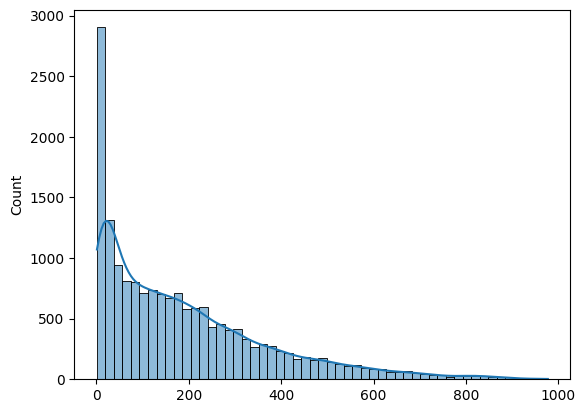

In [18]:
sns.histplot(data=list(raw_bikes["cnt"]), kde=True)

По графику понятно, что чаще всего кол-во ареднованных велосипедов оказывает около нуля. Длинный хвост справа

<Axes: ylabel='Count'>

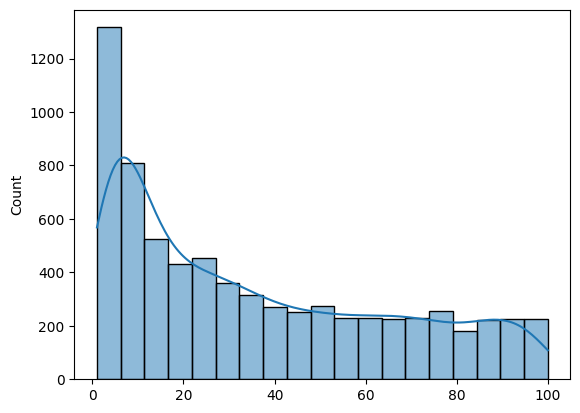

In [19]:
sns.histplot(data=list(raw_bikes[raw_bikes["cnt"] <= 100]["cnt"]), kde=True)

In [20]:
for i in range(0, 10):
    print(f"Кол-во значений {i}: {len(raw_bikes[raw_bikes["cnt"] == i])}")

Кол-во значений 0: 0
Кол-во значений 1: 158
Кол-во значений 2: 208
Кол-во значений 3: 224
Кол-во значений 4: 231
Кол-во значений 5: 260
Кол-во значений 6: 236
Кол-во значений 7: 198
Кол-во значений 8: 182
Кол-во значений 9: 128


На промежутке от 0 до 100 видно, что достотаточно часто кол-во велосипедов в аренде около нуля, однако значений 0 нет, мода от 0 до 9 = 5

### Погодные значения

Проведу анализ распределений погодных значений

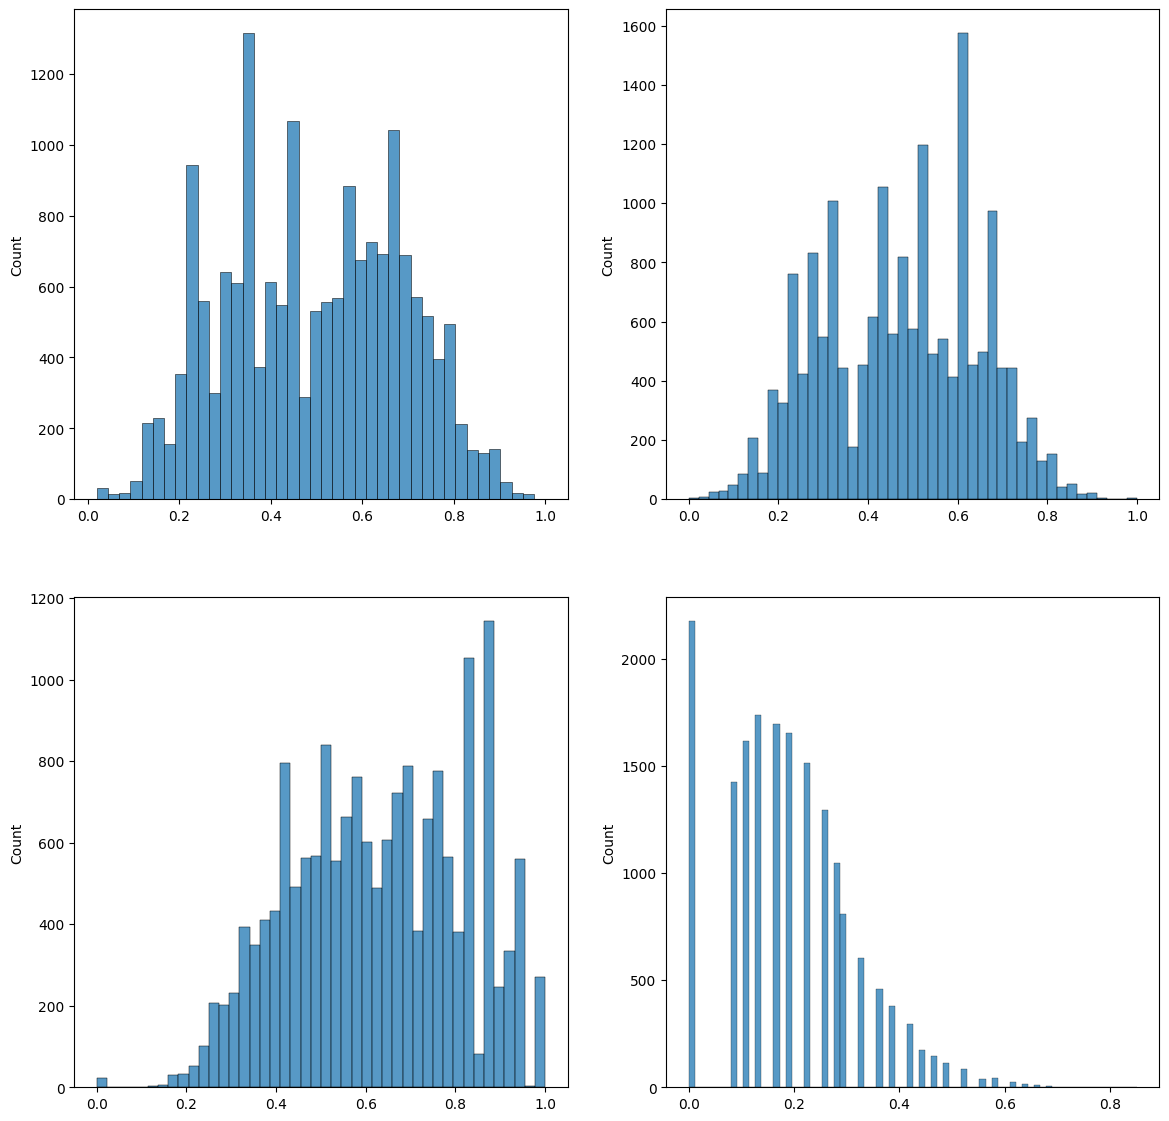

In [21]:
fig, ax = plt.subplots(2, 2)

cols = ["temp", "atemp", "hum", "windspeed"]

for i, axis in enumerate(ax.flatten()):
    sns.histplot(data=list(raw_bikes[cols[i]]), ax=axis)

fig.set_size_inches(14, 14)

По гистограммам понятно, что данные распределены бимодально, влажность и скорость ветра немного смещены

## Анализ по многим переменным

### Анализ количества аренды к времени

In [22]:
def quantile(x: pd.Series, workday: int, q: float) -> float:
    return x[raw_bikes.loc[x.index, "workingday"] == workday].quantile(q)

bikes_cnt_by_hr = raw_bikes.groupby("hr").agg(
    total_median=("cnt", "mean"),
    weekends_median=("cnt", lambda x: quantile(x, 0, 0.5)),
    weekends_q25=("cnt", lambda x: quantile(x, 0, 0.25)),
    weekends_q75=("cnt", lambda x: quantile(x, 0, 0.75)),

    workday_median=("cnt", lambda x: quantile(x, 1, 0.5)),
    workday_q25=("cnt", lambda x: quantile(x, 1, 0.25)),
    workday_q75=("cnt", lambda x: quantile(x, 1, 0.75)),
)

bikes_cnt_by_hr.head()

,total_median,weekends_median,weekends_q25,weekends_q75,workday_median,workday_q25,workday_q75
hr,,,,,,,
0,53.898072,93.5,46.25,122.75,33.0,21.0,48.0
1,33.375691,71.0,37.50,94.75,14.0,9.0,22.0
2,22.869930,54.0,29.75,72.25,7.0,4.0,12.0
3,11.727403,25.0,14.50,34.50,4.0,3.0,6.0
4,6.352941,7.0,4.00,12.00,5.0,3.0,7.0


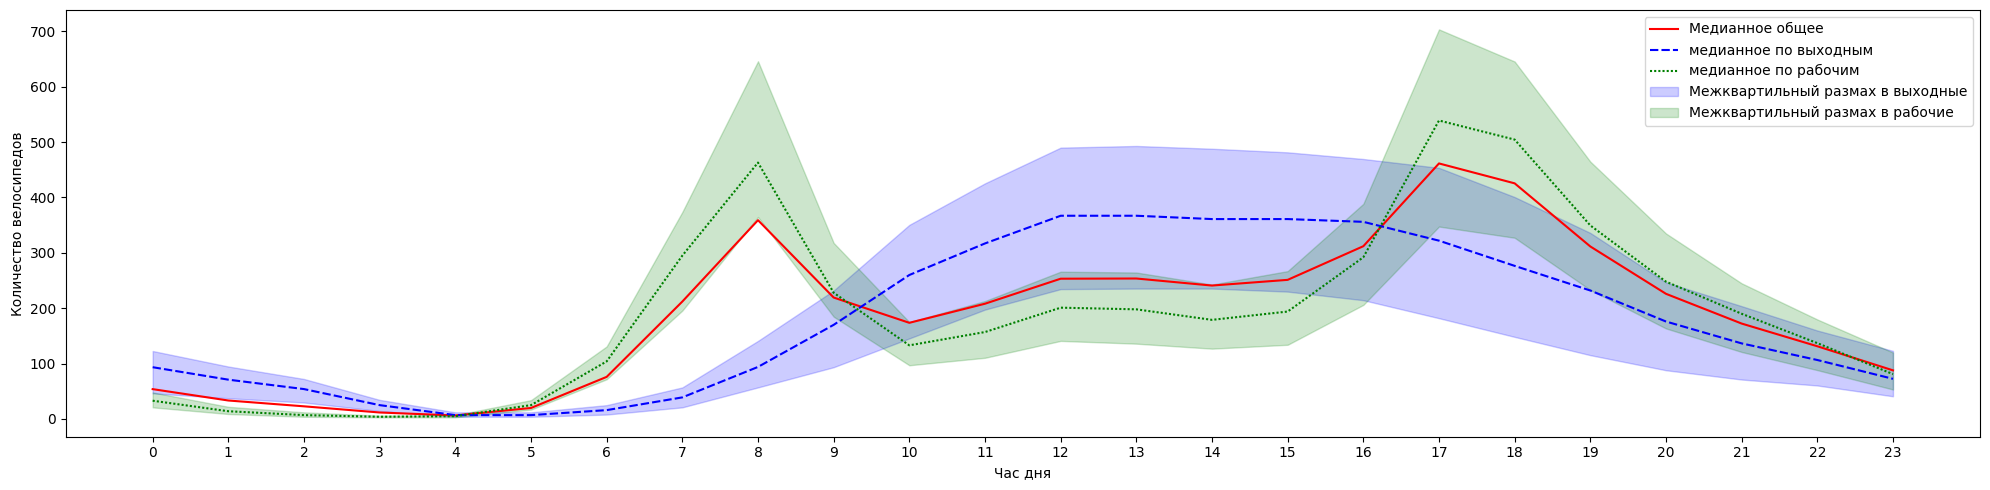

In [23]:
f, ax = plt.subplots(figsize=(20, 5))

bikes_plot = bikes_cnt_by_hr[
    ["total_median", "weekends_median", "workday_median"]
].copy()
bikes_plot.columns = [
    "Медианное общее",
    "медианное по выходным",
    "медианное по рабочим",
]

sns.lineplot(
    data=bikes_plot,
    ax=ax,
    palette=["red", "blue", "green"],
)

plt.fill_between(
    bikes_cnt_by_hr.index,
    bikes_cnt_by_hr["weekends_q25"],
    bikes_cnt_by_hr["weekends_q75"],
    alpha=0.2,
    color="blue",
    label="Межквартильный размах в выходные",
)

plt.fill_between(
    bikes_cnt_by_hr.index,
    bikes_cnt_by_hr["workday_q25"],
    bikes_cnt_by_hr["workday_q75"],
    alpha=0.2,
    color="green",
    label="Межквартильный размах в рабочие",
)

plt.xticks(range(0, 24))

plt.xlabel("Час дня")
plt.ylabel("Количество велосипедов")
plt.legend()
plt.tight_layout()
plt.show()

По графику видно, что:
- Для выходных и праздников самое популярное время аренды находится около обеденного времени (с 12 по 16). Это вероятно время прогулок, когда люди берут велосипеды для развлечения или спорта
- Для рабочих дней самое частое время это между 7 и 9 утра, а тажке около 17-18 часов. Тем самым можно предположить что люди арендуют велосипеды для поездки на работу и с работы

Также по общему среднему можно сделать вывод, что паттерн аренды в рабочее время перевешивает поведение людей в выходные, поэтому средее почти идеально попадает в межквартильный размах рабочего времени

### Анализ аномалий в погодных условиях

Для вычисления нормализованных значений полей windspeed (скорость ветра) и hum (влажность) было произведено делеление на максимальное значение, а не minmax нормализация. Это означает что в случаях когда значения равны 0, это действительно значение полученное с погодного датчика

windspeed == 0: 2180 rows
hum == 0:       22 rows


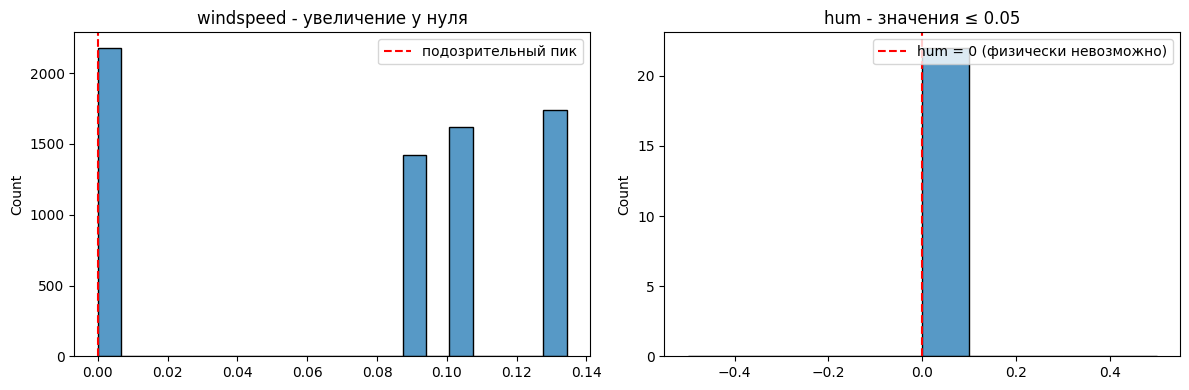

In [24]:
print("windspeed == 0:", (raw_bikes["windspeed"] == 0).sum(), "rows")
print("hum == 0:      ", (raw_bikes["hum"] == 0).sum(), "rows")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].set_title("windspeed - увеличение у нуля")
sns.histplot(list(raw_bikes[raw_bikes["windspeed"] <= 0.15]["windspeed"]),
             bins=20, ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--", label="подозрительный пик")
axes[0].legend()

axes[1].set_title("hum - значения ≤ 0.05")
sns.histplot(list(raw_bikes[raw_bikes["hum"] <= 0.05]["hum"]),
             bins=10, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--", label="hum = 0 (физически невозможно)")
axes[1].legend()

plt.tight_layout()
plt.show()

Как видно, некоторые значения скорости ветра равны 0, это довольно необычный пик с довольно большим количеством значений, но это довольно реальная ситуация для многих мест, так что эти значения можно оставить

Куда больше внимания стоит уделить значениям влажности. Как видно по гистограмме рядом фактически нет значений, и помимо этого, такие значений фактически невозможны на планете. Поэтому принял решение заменить эти значения на средние по тому же дню

In [25]:
daily_hum_mean = raw_bikes.groupby("dteday")["hum"].transform(
    lambda x: x[x > 0].mean()  # исключаем сами нули при подсчёте среднего
)

n_before = (raw_bikes["hum"] == 0).sum()
raw_bikes.loc[raw_bikes["hum"] == 0, "hum"] = daily_hum_mean[raw_bikes["hum"] == 0]
n_after = (raw_bikes["hum"] == 0).sum()

print(f"Заменено значений hum == 0: {n_before - n_after} (осталось нулей: {n_after})")

Заменено значений hum == 0: 22 (осталось нулей: 0)


### Анализ количества аренды по сезонам и типу погоды

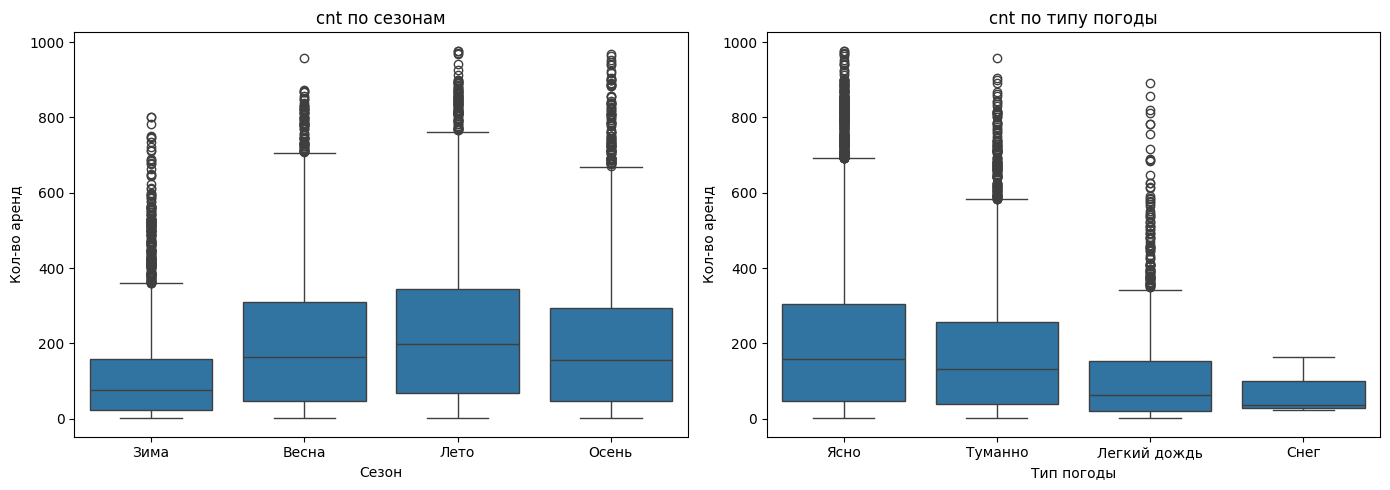

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_labels = {1: "Зима", 2: "Весна", 3: "Лето", 4: "Осень"}
weather_labels = {
    1: "Ясно",
    2: "Туманно",
    3: "Легкий дождь",
    4: "Снег",
}

seasonal = pd.DataFrame()
seasonal["cnt"] = raw_bikes["cnt"]
seasonal["season_label"] = raw_bikes["season"].map(season_labels)
seasonal["weather_label"] = raw_bikes["weathersit"].map(weather_labels)

season_order = list(season_labels.values())
weather_order = list(weather_labels.values())

sns.boxplot(data=seasonal, x="season_label", y="cnt", order=season_order, ax=axes[0])
axes[0].set_title("cnt по сезонам")
axes[0].set_xlabel("Сезон")
axes[0].set_ylabel("Кол-во аренд")

sns.boxplot(data=seasonal, x="weather_label", y="cnt", order=weather_order, ax=axes[1])
axes[1].set_title("cnt по типу погоды")
axes[1].set_xlabel("Тип погоды")
axes[1].set_ylabel("Кол-во аренд")

plt.tight_layout()
plt.show()


Результаты крайне ожидаемые, в теплые сезоны люди арендую чаще чем в холодные, однако в данных прослеживается региональная девиация - зимой люди все-же в довольно большом объеме берут велосипеды на прокат, что может намекать на теплый климат, или отсутствие постоянного снежного покрова

По погоде прослеживается похожая ситуация, в ясную погоду люди берут на прокат велосипеды чаще

Построю heatmap суммы по сезонам и погодам

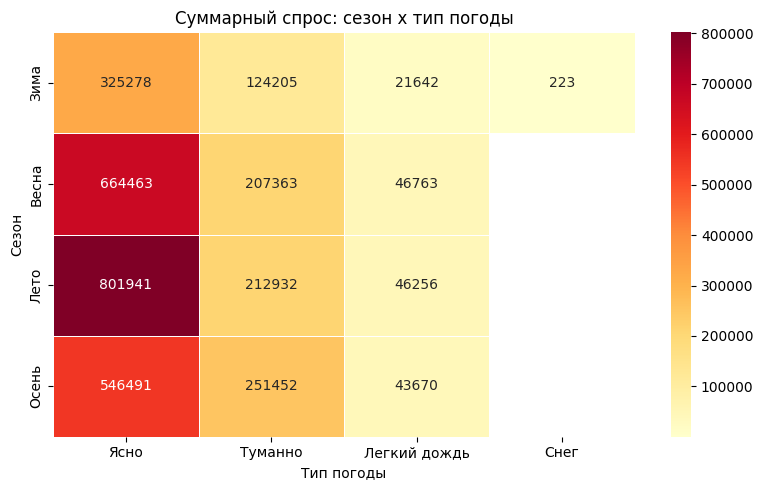

In [27]:
pivot = seasonal.groupby(["season_label", "weather_label"])["cnt"].sum().unstack()
pivot = pivot.reindex(index=season_order, columns=weather_order)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Суммарный спрос: сезон x тип погоды")
ax.set_xlabel("Тип погоды")
ax.set_ylabel("Сезон")
plt.tight_layout()
plt.show()

В целом, рельзультаты совпадают с ожидаемыми, самое большое кол-во аренд приходится на ясную погоду в теплые сезоны. Почти никто не решается бнать велосипеды в дождь или снег

Отсутствие значений осенью, летом и весной в снег ожидаемо - скорее всего в этом регионе снег выпадает только зимой, и достаточно редко

### Корреляция числовых признаков

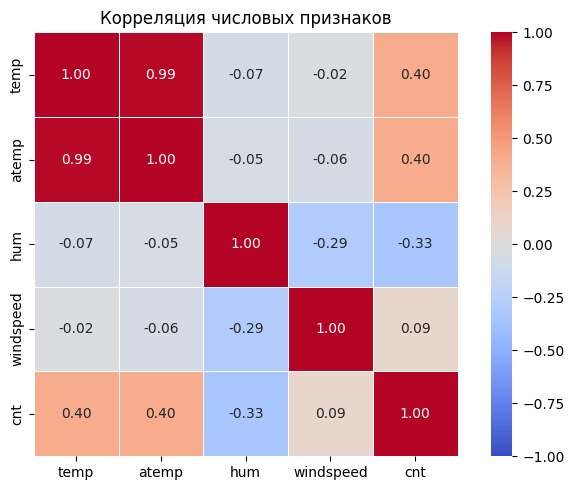

In [28]:
numeric_cols = ["temp", "atemp", "hum", "windspeed", "cnt"]
corr = raw_bikes[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, ax=ax,
            linewidths=0.5)
ax.set_title("Корреляция числовых признаков")
plt.tight_layout()
plt.show()

Очевидна сильная корреляция между temp и atemp (подсчитаны из одного исходного значения), также заметна корреляция между температурой и кол-вом аренодованных велосипедов.

Есть также слабамя отрицательная корреляция с hum и windspeed. Это связано с тем, что влажность сильно зависит от погоды, а судя по данным, люди мало берут в аренду велосипеды в условиях плохой погоды

# Выводы по EDA

- **Целевая переменная** имеет правосторонний хвост - при обучении стоит применить log1p-преобразование
- **Час дня** - главный предиктор: двумодальный паттерн в рабочие дни (8:00 и 17–18:00), одномодальный в выходные (12–16:00)
- **Температура** умеренно коррелирует с cnt (~0.40); temp и atemp взаимозаменяемы (r=0.99) - в модели достаточно одного
- **Сезонность**: лето > осень > весна > зима; зимний спрос ненулевой - климат DC не исключает аренду
- **Погода**: ясная погода дает максимальный спрос; категории 3 и 4 редки (~3% данных) - обоснование для их объединения при препроцессинге
- **Аномалии**: 22 строки hum=0 заменены средним по дню; windspeed=0 (~12.5%) оставлен как физически корректный

## Сохранение

In [29]:
raw_bikes.to_csv("datasets/eda.csv", index=False)